In [2]:
import numpy as np
from qgates import ZZ_Rotation, Z_Rotation, X_Rotation, X, I, Z
from tqdm import tqdm


def U_0(thetas: list[float], topology: str, size: int = 4):
    """
    Constructs a quantum gate that applies single qubit rotations in sequence.

    Parameters:
        thetas (list[float]): The rotation angles for the single qubit rotations.
        topology (str): The topology of the connections.
        size (int): The size of the quantum system (default is 4).

    Returns:
        QuantumGate: A quantum gate representing the combined single qubit rotations.
    """
    final_gate = None

    for i in range(size):
        if topology == "a3_no1Q" and i == size - 1:
            break
        gate_z = Z_Rotation(size, i, thetas[2 * i + 0], False)
        gate_x = X_Rotation(size, i, thetas[2 * i + 1], False)

        gate_q = gate_z @ gate_x
        final_gate = final_gate @ gate_q if final_gate is not None else gate_q

    return final_gate


def U_ent(thetas: list[float], topology: str, size: int = 4):
    """
    Constructs a quantum gate that applies two ZZ rotations in sequence.

    Parameters:
        thetas (list[float]): The rotation angles for the ZZ rotations.
        topology (str): The topology of the connections.
        size (int): The size of the quantum system (default is 4).

    Returns:
        QuantumGate: A quantum gate representing the combined ZZ rotations.
    """
    gate1 = ZZ_Rotation(size, 0, 1, thetas[0], False)
    gate2 = ZZ_Rotation(size, 1, 2, thetas[1], False)

    combined_gate = gate1 @ gate2

    if topology in {"a2", "a3", "a3_no1Q", "a4"}:
        gate3 = ZZ_Rotation(size, 0, 3, thetas[3], False)
        combined_gate @= gate3

    if topology in {"a2", "a4"}:
        gate4 = ZZ_Rotation(size, 1, 3, thetas[4], False)
        combined_gate @= gate4

    if topology in {"a1", "a3", "a4", "a3_no1Q"}:
        gate5 = ZZ_Rotation(size, 2, 3, thetas[2], False)
        combined_gate @= gate5

    return combined_gate


def ds1Qgates(thetas: list[float], topology: str, n_layers: int):
    """
    Constructs a quantum gate that applies a sequence of single qubit rotations
    followed by entangling ZZ rotations.

    Parameters:
        thetas (list[float]): The rotation angles for the single qubit and ZZ rotations.
        topology (str): The topology of the connections.
        n_layers (int): The number of layers on the generator.

    Returns:
        list[np.ndarray]: A list of quantum states representing the derivatives.
    """
    gate_single = []
    gate_ent = []
    for l in range(n_layers):
        gate_single.append(U_0(thetas[l * 8 : (l + 1) * 8], topology=topology))

    ent_start = 8 * n_layers
    for l in range(n_layers):
        gate_ent.append(U_ent(thetas[ent_start + l * 5 : ent_start + (l + 1) * 5], topology=topology))

    zero_state = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]).transpose()
    ds = []

    for l in range(n_layers):
        for pauli in [X, Z]:
            for qubit in range(4):
                if topology == "a3_no1Q" and qubit == 3:
                    continue

                if qubit == 0:
                    P = np.kron(np.kron(np.kron(I, I), I), pauli)
                elif qubit == 1:
                    P = np.kron(np.kron(np.kron(I, I), pauli), I)
                elif qubit == 2:
                    P = np.kron(np.kron(np.kron(I, pauli), I), I)
                elif qubit == 3:
                    P = np.kron(np.kron(np.kron(pauli, I), I), I)

                op = P

                # Apply suffix (gates after P)
                op = gate_ent[l] @ op
                for k in range(l + 1, n_layers):
                    op = gate_ent[k] @ gate_single[k] @ op

                # Apply prefix (gates before P)
                op = op @ gate_single[l]
                for k in range(l - 1, -1, -1):
                    op = op @ gate_ent[k] @ gate_single[k]

                ds.append(op @ zero_state)

    return ds


def ds2Qgates(thetas: list[float], topology: str, n_layers: int) -> list[np.ndarray]:
    """
    Constructs a quantum gate that applies a sequence of single qubit rotations
    followed by entangling ZZ rotations.

    Parameters:
        thetas (list[float]): The rotation angles for the single qubit and ZZ rotations.
        topology (str): The topology of the connections.
        n_layers (int): The number of layers on the generator.

    Returns:
        list[np.ndarray]: A list of quantum states representing the derivatives.
    """
    gate_single = []
    gate_ent = []
    for l in range(n_layers):
        gate_single.append(U_0(thetas[l * 8 : (l + 1) * 8], topology=topology))

    ent_start = 8 * n_layers
    for l in range(n_layers):
        gate_ent.append(U_ent(thetas[ent_start + l * 5 : ent_start + (l + 1) * 5], topology=topology))

    zero_state = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]).transpose()
    ds = []

    for l in range(n_layers):
        for P_name in ["01", "12", "03", "13", "23"]:
            if P_name == "03" and topology not in {"a2", "a3", "a3_no1Q", "a4"}:
                continue
            if P_name == "13" and topology not in {"a2", "a4"}:
                continue
            if P_name == "23" and topology not in {"a1", "a3", "a4", "a3_no1Q"}:
                continue

            if P_name == "01":
                P = np.kron(np.kron(np.kron(Z, Z), I), I)
            elif P_name == "12":
                P = np.kron(np.kron(np.kron(I, Z), Z), I)
            elif P_name == "03":
                P = np.kron(np.kron(np.kron(Z, I), I), Z)
            elif P_name == "13":
                P = np.kron(np.kron(np.kron(I, Z), I), Z)
            elif P_name == "23":
                P = np.kron(np.kron(np.kron(I, I), Z), Z)

            op = P

            # Apply suffix (gates after P)
            for k in range(l + 1, n_layers):
                op = gate_ent[k] @ gate_single[k] @ op

            # Apply prefix (gates before P)
            op = op @ gate_ent[l] @ gate_single[l]
            for k in range(l - 1, -1, -1):
                op = op @ gate_ent[k] @ gate_single[k]

            ds.append(op @ zero_state)

    return ds


def count_linearly_independent(arrays: list[np.ndarray], rtol=None) -> int:
    """
    Counts the number of linearly independent arrays in the given list.

    Parameters:
        arrays (list[np.ndarray]): A list of arrays.
        rtol (float): Relative tolerance respect maximum eigenvalue to consider it 0.

    Returns:
        int: The number of linearly independent arrays.
    """
    if not arrays:
        return 0

    # Stack the arrays to form a matrix
    # The rank of the matrix corresponds to the number of linearly independent rows (or columns)
    matrix = np.stack(arrays)
    return np.linalg.matrix_rank(matrix, rtol=rtol)


def compute_all_ds(thetas: list[float], topology: str, n_layers: int) -> list[np.ndarray]:
    """
    Computes the expressivity of a quantum circuit defined by the given angles.

    Parameters:
        thetas (list[float]): The rotation angles for the quantum circuit.
        topology (str): The topology of the connections.
        n_layers (int): The number of layers on the generator.

    Returns:
        list[np.ndarray]: A list of quantum states resulting from the circuit.
    """
    len_thetas_must_be = 0

    if topology == "a3_no1Q":
        len_thetas_must_be = 10 * n_layers
    elif topology == "a1":
        len_thetas_must_be = 11 * n_layers
    elif topology in {"a2", "a3"}:
        len_thetas_must_be = 12 * n_layers
    elif topology == "a4":
        len_thetas_must_be = 13 * n_layers

    if len(thetas) < len_thetas_must_be:
        raise ValueError(f"Expected {len_thetas_must_be} angles, but got {len(thetas)}.")

    states_1Qgates = ds1Qgates(thetas, topology=topology, n_layers=n_layers)
    states_2Qgates = ds2Qgates(thetas, topology=topology, n_layers=n_layers)

    return states_1Qgates + states_2Qgates


def compute_expresivity(thetas: list[float], topology: str, n_layers: int, rtol=None) -> int:
    """
    Computes the expressivity of a quantum circuit defined by the given angles.

    Parameters:
        thetas (list[float]): The rotation angles for the quantum circuit.
        topology (str): The topology of the connections.
        n_layers (int): The number of layers on the generator.
        rtol (float): Relative tolerance respect maximum eigenvalue, to consider 0.

    Returns:
        int: The expressivity of the given topology
    """
    ds_states = compute_all_ds(thetas, topology=topology, n_layers=n_layers)
    return int(count_linearly_independent(ds_states, rtol))

# 1 Layer:

In [ ]:
angle = 0
thetas = [angle for _ in range(26)]

a1, a2, a3, a3_no1Q, a4 = (
    compute_expresivity(thetas, topology=topology, n_layers=1) for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
)

print(a1, a2, a3, a3_no1Q, a4)

5 5 5 4 5


In [ ]:
angle = 1
thetas = [angle for _ in range(26)]

a1, a2, a3, a3_no1Q, a4 = (
    compute_expresivity(thetas, topology=topology, n_layers=1) for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
)

print(a1, a2, a3, a3_no1Q, a4)

8 9 9 7 10


In [ ]:
tries = 1000

# rtol = 0.25
for rtol in [None, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.8]:
    a1_list, a2_list, a3_list, a3_no1Q_list, a4_list = [], [], [], [], []
    for _ in tqdm(range(tries)):
        thetas = np.random.uniform(0, 2 * np.pi, 26).tolist()
        a1, a2, a3, a3_no1Q, a4 = (
            compute_expresivity(thetas, topology=topology, n_layers=1, rtol=rtol)
            for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
        )

        for list, instance in zip([a1_list, a2_list, a3_list, a3_no1Q_list, a4_list], [a1, a2, a3, a3_no1Q, a4]):
            list.append(instance)

    print("RTOL: ", rtol)
    print(np.mean(a1_list), np.mean(a2_list), np.mean(a3_list), np.mean(a3_no1Q_list), np.mean(a4_list), "\n")

100%|██████████| 1000/1000 [00:20<00:00, 48.46it/s]


RTOL:  None
8.0 9.0 9.0 7.0 10.0 



100%|██████████| 1000/1000 [00:21<00:00, 46.82it/s]


RTOL:  0.01
7.787 8.687 8.694 6.826 9.599 



100%|██████████| 1000/1000 [00:21<00:00, 47.62it/s]


...

RTOL:  0.25
5.805 6.032 6.035 5.148 6.252 



100%|██████████| 1000/1000 [00:19<00:00, 51.83it/s]


RTOL:  0.5
3.839 3.67 3.707 2.982 3.591 



100%|██████████| 1000/1000 [00:19<00:00, 51.55it/s]

RTOL:  0.8
1.276 1.315 1.321 1.168 1.352 



# 2 Layers:

In [ ]:
angle = 0
thetas = [angle for _ in range(26)]

a1, a2, a3, a3_no1Q, a4 = (
    compute_expresivity(thetas, topology=topology, n_layers=2) for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
)

print(a1, a2, a3, a3_no1Q, a4)

5 5 5 4 5


In [ ]:
angle = 1
thetas = [angle for _ in range(26)]

a1, a2, a3, a3_no1Q, a4 = (
    compute_expresivity(thetas, topology=topology, n_layers=2) for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
)

print(a1, a2, a3, a3_no1Q, a4)

13 14 16 10 16


In [ ]:
tries = 1000

# rtol = 0.25
for rtol in [None, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.8]:
    a1_list, a2_list, a3_list, a3_no1Q_list, a4_list = [], [], [], [], []
    for _ in tqdm(range(tries)):
        thetas = np.random.uniform(0, 2 * np.pi, 26).tolist()
        a1, a2, a3, a3_no1Q, a4 = (
            compute_expresivity(thetas, topology=topology, n_layers=2, rtol=rtol)
            for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
        )

        for list, instance in zip([a1_list, a2_list, a3_list, a3_no1Q_list, a4_list], [a1, a2, a3, a3_no1Q, a4]):
            list.append(instance)

    print("RTOL: ", rtol)
    print(np.mean(a1_list), np.mean(a2_list), np.mean(a3_list), np.mean(a3_no1Q_list), np.mean(a4_list), "\n")

100%|██████████| 1000/1000 [00:39<00:00, 25.51it/s]


RTOL:  None
13.0 14.0 16.0 10.0 16.0 



100%|██████████| 1000/1000 [00:39<00:00, 25.50it/s]


RTOL:  0.01
10.706 12.224 13.494 9.261 14.201 



100%|██████████| 1000/1000 [00:39<00:00, 25.28it/s]


...

RTOL:  0.25
6.974 7.493 7.565 6.244 8.064 



100%|██████████| 1000/1000 [00:38<00:00, 25.82it/s]


RTOL:  0.5
4.703 4.576 4.6 3.381 4.516 



100%|██████████| 1000/1000 [00:38<00:00, 26.02it/s]

RTOL:  0.8
1.426 1.422 1.489 1.298 1.502 



# Layers 3:

In [ ]:
angle = 0
thetas = [angle for _ in range(39)]

a1, a2, a3, a3_no1Q, a4 = (
    compute_expresivity(thetas, topology=topology, n_layers=3) for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
)

print(a1, a2, a3, a3_no1Q, a4)

5 5 5 4 5


In [ ]:
angle = 1
thetas = [angle for _ in range(39)]

a1, a2, a3, a3_no1Q, a4 = (
    compute_expresivity(thetas, topology=topology, n_layers=3) for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
)

print(a1, a2, a3, a3_no1Q, a4)

16 16 16 11 16


In [ ]:
tries = 1000

# rtol = 0.25
for rtol in [None, 0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.8]:
    a1_list, a2_list, a3_list, a3_no1Q_list, a4_list = [], [], [], [], []
    for _ in tqdm(range(tries)):
        thetas = np.random.uniform(0, 2 * np.pi, 39).tolist()
        a1, a2, a3, a3_no1Q, a4 = (
            compute_expresivity(thetas, topology=topology, n_layers=3, rtol=rtol)
            for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
        )

        for list, instance in zip([a1_list, a2_list, a3_list, a3_no1Q_list, a4_list], [a1, a2, a3, a3_no1Q, a4]):
            list.append(instance)

    print("RTOL: ", rtol)
    print(np.mean(a1_list), np.mean(a2_list), np.mean(a3_list), np.mean(a3_no1Q_list), np.mean(a4_list), "\n")

100%|██████████| 1000/1000 [01:01<00:00, 16.30it/s]


RTOL:  None
16.0 16.0 16.0 11.0 16.0 



100%|██████████| 1000/1000 [01:00<00:00, 16.47it/s]


RTOL:  0.01
12.775 14.674 15.679 10.816 15.841 



100%|██████████| 1000/1000 [00:59<00:00, 16.67it/s]


...

RTOL:  0.25
7.812 8.714 8.835 7.079 9.632 



100%|██████████| 1000/1000 [00:59<00:00, 16.80it/s]


RTOL:  0.5
5.258 5.233 5.232 3.657 5.271 



100%|██████████| 1000/1000 [00:59<00:00, 16.93it/s]

RTOL:  0.8
1.522 1.529 1.584 1.38 1.57 



In [ ]:
tries = 1000

# rtol = 0.25
for rtol in [0.0002, 0.002, 0.02]:
    a1_list, a2_list, a3_list, a3_no1Q_list, a4_list = [], [], [], [], []
    for _ in tqdm(range(tries)):
        thetas = np.random.uniform(0, 2 * np.pi, 39).tolist()
        a1, a2, a3, a3_no1Q, a4 = (
            compute_expresivity(thetas, topology=topology, n_layers=3, rtol=rtol)
            for topology in ["a1", "a2", "a3", "a3_no1Q", "a4"]
        )

        for list, instance in zip([a1_list, a2_list, a3_list, a3_no1Q_list, a4_list], [a1, a2, a3, a3_no1Q, a4]):
            list.append(instance)

    print("RTOL: ", rtol)
    print(np.mean(a1_list), np.mean(a2_list), np.mean(a3_list), np.mean(a3_no1Q_list), np.mean(a4_list), "\n")

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:02<00:00, 16.03it/s]


RTOL:  0.0002
15.176 15.92 15.999 10.999 16.0 



100%|██████████| 1000/1000 [00:59<00:00, 16.69it/s]


RTOL:  0.002
14.128 15.63 15.968 10.983 15.987 



100%|██████████| 1000/1000 [00:59<00:00, 16.73it/s]

RTOL:  0.02
12.052 13.937 15.142 10.593 15.517 



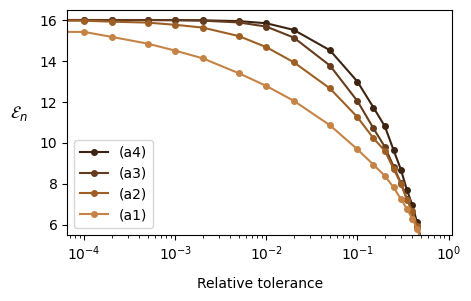

In [ ]:
x = [0, 0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

a1 = [
    16.0,
    15.419,
    15.176,
    14.844,
    14.503,
    14.128,
    13.397,
    12.775,
    12.052,
    10.854,
    9.679,
    8.925,
    8.382,
    7.812,
    7.253,
    6.758,
    6.294,
    5.805,
    5.258,
]
a2 = [
    16.0,
    15.966,
    15.92,
    15.873,
    15.766,
    15.63,
    15.213,
    14.674,
    13.937,
    12.653,
    11.254,
    10.218,
    9.607,
    8.714,
    8.007,
    7.212,
    6.678,
    5.93,
    5.233,
]
a3 = [
    16.0,
    16.0,
    15.999,
    15.999,
    15.99,
    15.968,
    15.881,
    15.679,
    15.142,
    13.771,
    12.039,
    10.706,
    9.798,
    8.835,
    8.026,
    7.253,
    6.62,
    5.924,
    5.232,
]
a4 = [
    16.0,
    16.0,
    16.0,
    16.0,
    15.996,
    15.987,
    15.947,
    15.841,
    15.517,
    14.519,
    12.989,
    11.722,
    10.803,
    9.632,
    8.69,
    7.685,
    6.957,
    6.128,
    5.271,
]

colors = ["#C68346", "#9E5F24", "#663C1F", "#3D2412"]

# Plot in a single figure y_X against x, with a single line for each index of y_X evolving with X, and a legend with the name of the topology
import matplotlib
import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# for i, y in enumerate([a1, a2, a3, a4]):
#     plt.plot(x, y, label=f"(a{i + 1})", marker="o", color=colors[i])

# plt.xlabel("RTOL")
# plt.ylabel("Rank of Jacobian")
# plt.legend()
# plt.grid(True)
# plt.show()


# Can you change the figure to show the points as well as the lines, and use a logarithmic scale for the x-axis?
fig, ax = plt.subplots(figsize=(5, 3))
for i, y in enumerate([a4, a3, a2, a1]):
    ax.plot(x, y, label=f"(a{4 - i})", marker="o", color=colors[4 - i - 1], markersize=4)

# Add the xtick 0.5 to the figure:

fig.subplots_adjust(left=0.15, bottom=0.2, right=0.92, top=0.95, wspace=None, hspace=None)

ax.set_xlabel("Relative tolerance", labelpad=10)
plt.ylabel(r"$\mathcal{E}_n$", rotation=0, fontsize=12, labelpad=15)
plt.xscale("log")
ax.set_ylim(5.5, 16.5)
ax.set_xlim(None, 1.1)
ax.set_xticks(
    ticks=[0.0001, 0.001, 0.01, 0.1, 1], labels=[r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$"]
)
plt.legend()
plt.grid(False)
plt.show()
# Save the final figure as a png, and name it "expressivity_rtol.png"
fig.savefig("expressivity_rtol.png")